In [1]:
import torch
import numpy as np
import normflows as nf

import sys
import os
c_directory = os.getcwd()
sys.path.append(os.path.dirname(c_directory))
sys.path.append(os.path.join(os.path.dirname(c_directory), 'FCYeast'))

from matplotlib import pyplot as plt
#from eZplot import FCBSCD_plot
from tqdm import tqdm

import FCYeast_simulator

#import gc

enable_cuda = True
CUDA_LAUNCH_BLOCKING=1
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

FCYeast_simulator.adjust_device(device)

l10 = np.log(10)

/home/pessoa/Codes/SBI-Final/FC-inference/FCYeast/FCYeast_simulator.py:21: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  autofluo.load_state_dict(torch.load('autofluorescenc

In [2]:
bh = 442413.
bl = bh/100

bl = 1e4

In [3]:
dils = [.12,.23,.33]

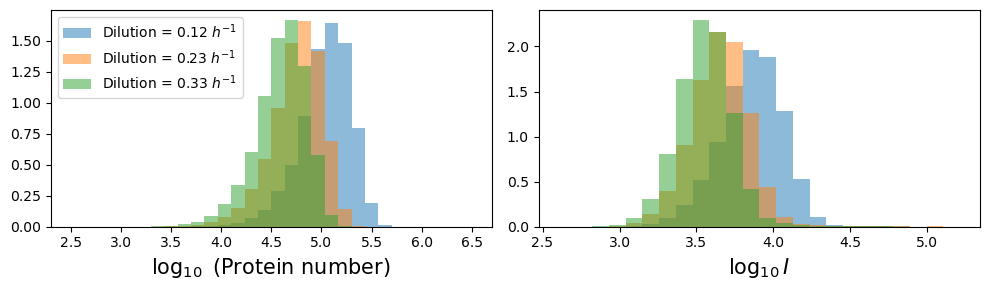

In [7]:

bins = np.linspace(6, 12, 25)/l10

fig, axs = plt.subplots(1, 2, figsize=(10, 3), tight_layout=True)

for dil in dils:
    # Simulate protein levels
    t, Pr, s = FCYeast_simulator.simulator(
        torch.tensor((bl, bh), device=device) / dil,
        torch.tensor((0, 10), device=device),
        .1,N=1000*100
    )

    # Convert protein count to intensity
    I_prot = FCYeast_simulator.prot2intensity(Pr)

    # Log of total intensity (protein + autofluorescence)
    lI = torch.logaddexp(
        FCYeast_simulator.autofluo.sample(Pr.numel())[0],
        torch.log(I_prot)
    )

    # Plot log intensity histogram
    axs[1].hist(lI.cpu().reshape(-1).numpy()/l10, 
                bins=bins, 
                density=True, 
                alpha=0.5)

    # Plot log protein histogram with clamp
    axs[0].hist(
        torch.log10(torch.clamp(Pr, min=1)).cpu().reshape(-1).numpy(),
        bins=np.linspace(2.5,6.5,31),
        density=True,
        label = r'Dilution = {} $h^{{-1}}$'.format(dil),
        alpha=0.5
    )

axs[0].set_xlabel(r'$\log_{10}$ (Protein number) ',fontsize=15)
axs[1].set_xlabel(r'$\log_{10} I$',fontsize=15)
axs[0].legend()

plt.savefig('SI2',dpi=600)
plt.show()
